# Import

Import all necessary libraries. If you face any issue, please install the libraries using pip or conda.

Ensure reproducibility of your code and keep reusing your functions in all assignments.

**Note: NetworkX must not be used in your solution except for explicitly stated**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import sys

In [2]:
# change this to the filename you want to read
undirected_network_edges = "undirected_network_edge_list.csv"
directed_network_edges = "directed_network_edge_list.csv"

# don't change this part
if len(sys.argv) > 2 and 'ipykernel' not in sys.modules:
    print("Running in shell, reading filename from command line argument")
    undirected_network_edges = sys.argv[1]
    directed_network_edges = sys.argv[2]

# Getting started

Paste all your previous functions here. This will become your library of functions that you can reuse in all assignments.

In [3]:
def read_network(filename, directed=False):
    pass
    # read edge list into df
    df = pd.read_csv(undirected_network_edges)
    
    # sort the node IDs into node_list
    all_nodes = set(df['from']) | set(df['to'])
    node_list = np.array(sorted(list(all_nodes)))
    
    # convert df into adjacency matrix adj ordered by node_list
    n = len(node_list)
    adj = np.zeros((n, n), dtype=int)
    
    node_to_index = {node: i for i, node in enumerate(node_list)}
    
    # Fill the adjacency matrix
    for _, row in df.iterrows():
        source = row['from']
        target = row['to']
        i = node_to_index[source]
        j = node_to_index[target]
        adj[i, j] = 1
        
        # If undirected, also set the symmetric entry
        if not directed:
            adj[j, i] = 1
    
    # read the edge list using NetworkX into G
    if directed:
        G = nx.from_pandas_edgelist(df, source='from', target='to', edge_attr='weight', 
                                   create_using=nx.DiGraph())
    else:
        G = nx.from_pandas_edgelist(df, source='from', target='to', edge_attr='weight')
    
    return adj, node_list, G
   

In [4]:
# need to be run
adj, node_list, G = read_network(undirected_network_edges, directed=False)

In [5]:
def clustering_coefficient(adj, is_directed=False):
    pass
    # Step 1: Symmetrize if directed (treat as undirected for clustering)
    if is_directed:
        adj_sym = (adj + adj.T > 0).astype(int)  # Union of edges in both directions
    else:
        adj_sym = adj
    
    n = adj_sym.shape[0]  # number of nodes
    clustering_coeffs = np.zeros(n)
    
    # Step 2: For each node, compute its clustering coefficient
    for i in range(n):
        # Find neighbors of node i
        neighbors = np.where(adj_sym[i] == 1)[0]
        k_i = len(neighbors)  # degree of node i
        
        # If node has 0 or 1 neighbors, clustering coefficient is 0 (undefined, set to 0)
        if k_i < 2:
            clustering_coeffs[i] = 0.0
            continue
        
        # Step 3: Count edges between neighbors
        # Extract the subgraph of neighbors
        edges_between_neighbors = 0
        for idx1 in range(len(neighbors)):
            for idx2 in range(idx1 + 1, len(neighbors)):
                neighbor1 = neighbors[idx1]
                neighbor2 = neighbors[idx2]
                # Check if there's an edge between neighbor1 and neighbor2
                if adj_sym[neighbor1, neighbor2] == 1:
                    edges_between_neighbors += 1
        
        # Step 4: Compute clustering coefficient
        # Maximum possible edges = k_i * (k_i - 1) / 2
        max_possible_edges = k_i * (k_i - 1) / 2
        clustering_coeffs[i] = edges_between_neighbors / max_possible_edges
    
    # Step 5: Compute average clustering coefficient
    average_clustering_coeff = np.mean(clustering_coeffs)
    
    return clustering_coeffs, average_clustering_coeff

In [6]:
def largest_connected_component(adj):
    pass
    n = adj.shape[0]  # number of nodes
    visited = np.zeros(n, dtype=bool)  # track visited nodes
    components = []  # store all connected components
    
    # Helper function: BFS to find one connected component starting from node 'start'
    def bfs(start):
        component = set()
        queue = [start]
        visited[start] = True
        
        while queue:
            node = queue.pop(0)
            component.add(node)
            
            # Find all neighbors of current node
            neighbors = np.where(adj[node] == 1)[0]
            
            for neighbor in neighbors:
                if not visited[neighbor]:
                    visited[neighbor] = True
                    queue.append(neighbor)
        
        return component
    
    # Find all connected components
    for node in range(n):
        if not visited[node]:
            component = bfs(node)
            components.append(component)
    
    # Find the largest connected component (in terms of indices)
    lcc_indices = max(components, key=len)
    
    # Map indices back to original node IDs using node_list
    lcc_node_list = {node_list[idx] for idx in lcc_indices}
    
    return lcc_node_list

In [7]:
def ER_graph_generator(n, p, seed=0):
    pass
    # Step 1: Fix the random seed
    rng = np.random.Generator(np.random.PCG64(seed))
    
    # Step 2: Generate the graph
    # Create random matrix where each entry is 1 with probability p
    adj = (rng.random((n, n)) < p).astype(int)
    
    # Step 3: Remove self-loops (set diagonal to 0)
    np.fill_diagonal(adj, 0)
    
    # Step 4: Make the graph undirected
    # Use upper triangular part and mirror it to lower triangular part
    adj = np.triu(adj)  # Keep only upper triangular part
    adj = adj + adj.T   # Add transpose to make symmetric
    
    # Step 5: Return the adjacency matrix
    return adj

In [8]:
def degree(adj):
    pass
    degrees = np.sum(adj, axis=1)
    return degrees

In [9]:
def Configuration_model_generator(deg_seq, seed=0):
    pass
     # Step 1: Fix the random seed
    rng = np.random.Generator(np.random.PCG64(seed))
    
    # Step 2: Initialize the graph with no edges
    n = len(deg_seq)
    adj = np.zeros((n, n), dtype=int)
    
    # Step 3: Create a list of stubs (half-edges)
    # Each node i appears deg_seq[i] times in the stub list
    stubs = []
    for node, degree in enumerate(deg_seq):
        stubs.extend([node] * degree)
    
    # Convert to numpy array for easier manipulation
    stubs = np.array(stubs)
    
    # Step 4: Randomly shuffle the stubs
    rng.shuffle(stubs)
    
    # Step 5: Pair up stubs to create edges
    # Take pairs of stubs and connect them
    for i in range(0, len(stubs) - 1, 2):
        node1 = stubs[i]
        node2 = stubs[i + 1]
        
        # Add edge (allows self-loops and multi-edges)
        adj[node1, node2] += 1
        adj[node2, node1] += 1
    
    # Step 6: Return the adjacency matrix
    return adj

# Question 1 (5 marks)

Design a function that generates a WS undirected random graph. Your graph cannot have self-loops or multiple edges.

1) Start with a ring lattice
2) Save the edges
3) Rewire the edges with probability `p`
4) Check if the new edge exists or if it is a self-loop, if so, discard it and try again
5) Return the adjacency matrix of the graph

In [10]:
def WS_graph_generator(n, k, p, seed=0):
    """
    Generate an undirected WS random graph with n nodes, starting with degree k and rewiring probability p.
    Your graph cannot have self-loops or multiple edges.
    Args:
        n: number of nodes (int)
        k: initial average degree (int, must be even)
        p: probability of rewiring (float)
        seed: random seed (int)
    Returns:
        adj: adjacency matrix of the generated WS graph (numpy array)
    """

    rng = np.random.Generator(np.random.PCG64(seed))
    pass
    # Step 1: Start with a ring lattice
    # Initialize adjacency matrix
    adj = np.zeros((n, n), dtype=int)
    
    # Connect each node to its k/2 nearest neighbors on each side
    for i in range(n):
        for j in range(1, k // 2 + 1):
            neighbor = (i + j) % n  # Wrap around using modulo
            adj[i, neighbor] = 1
            adj[neighbor, i] = 1
    
    # Step 2: Save the edges (we'll iterate through half of them to avoid duplication)
    # We only need to consider edges where i < j to avoid processing each edge twice
    edges_to_rewire = []
    for i in range(n):
        for j in range(i + 1, n):
            if adj[i, j] == 1:
                edges_to_rewire.append((i, j))
    
    # Step 3: Rewire edges with probability p
    for i, j in edges_to_rewire:
        # Rewire with probability p
        if rng.random() < p:
            # Remove the old edge
            adj[i, j] = 0
            adj[j, i] = 0
            
            # Step 4: Find a new target node (keep source node i)
            # Try to connect i to a new node that isn't i itself and doesn't already have an edge
            max_attempts = 100  # Prevent infinite loops
            rewired = False
            
            for _ in range(max_attempts):
                # Pick a random target node
                new_target = rng.integers(0, n)
                
                # Check if valid: not a self-loop and edge doesn't already exist
                if new_target != i and adj[i, new_target] == 0:
                    # Add the new edge
                    adj[i, new_target] = 1
                    adj[new_target, i] = 1
                    rewired = True
                    break
            
            # If we couldn't rewire after many attempts, keep the original edge
            if not rewired:
                adj[i, j] = 1
                adj[j, i] = 1
    
    # Step 5: Return the adjacency matrix
    return adj


# Question 2 (5 marks)

Design a function to generate BA undirected random graph.

1) Start with a small fully-connected network of `m0` nodes
2) Add a new node with `m` edges that link the new node to `m` different nodes already present in the network. The probability that a new node will be connected to node `i` is proportional to the degree of node `i`.
3) Repeat step 2 until the network has `n` nodes

In [11]:
def BA_random_graph_generator(m0, m, n, seed=0):
    """
    Generate an undirected BA random graph with n nodes, starting with m0 nodes and adding m edges for each new node.
    Args:
        m0: initial number of nodes (int)
        m: number of edges to attach from the new node to existing nodes (int)
        n: total number of nodes in the graph (int)
        seed: random seed (int)
    Returns:
        adj: adjacency matrix of the generated BA graph (numpy array)
    """

    assert m0>=m, "m0 must be greater than or equal to m"
    rng = np.random.Generator(np.random.PCG64(seed))

    pass
    # Step 1: Start with a small fully-connected network of m0 nodes
    adj = np.zeros((n, n), dtype=int)
    
    # Create fully connected initial network
    for i in range(m0):
        for j in range(i + 1, m0):
            adj[i, j] = 1
            adj[j, i] = 1
    
    # Step 2 & 3: Add new nodes one by one
    for new_node in range(m0, n):
        # Get current degrees of all existing nodes
        degrees = np.sum(adj[:new_node, :new_node], axis=1)
        
        # Calculate probabilities proportional to degree
        # Probability that new node connects to node i is proportional to degree of i
        total_degree = np.sum(degrees)
        
        if total_degree == 0:
            # If all degrees are 0 (shouldn't happen with m0 fully connected), use uniform
            probabilities = np.ones(new_node) / new_node
        else:
            probabilities = degrees / total_degree
        
        # Select m different nodes to connect to (without replacement)
        # Use preferential attachment based on degree
        targets = rng.choice(new_node, size=m, replace=False, p=probabilities)
        
        # Add edges from new_node to selected targets
        for target in targets:
            adj[new_node, target] = 1
            adj[target, new_node] = 1
    
    return adj

# Question 3 (3 marks)

Design a function to compute the average shortest path distance of the largest connected component of the provided `undirected_network`. Note that you are allowed to use NetworkX for this question.

1) Extract the largest connected component
2) Map the node list of the LCC to the indices of the adjacency matrix
3) Compute the average shortest path distance of the largest connected component using NetworkX

In [17]:
def average_path_distance(adj):
    """
    Compute the average shortest path distance of the largest connected component of the provided undirected network.
    Note that this function only work for the provided undirected network data.
    Note that you are allowed to use NetworkX for this function.
    Args:
        adj: adjacency matrix (numpy array)
    Returns:
        avg_path_length: distance (float)
    """
    
    pass
    # Step 1: Extract the largest connected component (returns indices, not node IDs)
    lcc_indices = largest_connected_component(adj)
    
    # Convert set to sorted list
    lcc_indices_list = sorted(list(lcc_indices))
    
    # Step 2: Extract subgraph adjacency matrix using np.ix_
    lcc_adj = adj[np.ix_(lcc_indices_list, lcc_indices_list)]
    
    # Step 3: Compute average shortest path using NetworkX
    G_lcc = nx.from_numpy_array(lcc_adj)
    avg_path_length = nx.average_shortest_path_length(G_lcc)
    
    return avg_path_length

# Question 4 (2 marks)

Use your function to compute a data sheet for comparing:
- average clustering coefficient
- average shortest path distance

of 

- real graph
- ER graph with same number of nodes and edge density
- graph from the Configuration Model with the same degree sequence
- WS graph with same number of nodes, starting with the same average degree (roughly) and any rewiring probability `p`
- BA graph with same number of nodes and any `m0` and `m`

Note that for random graphs, you should use the function `average_path_distance_random_graph` provided to compute the distance.

In [ ]:
def average_path_distance_random_graph(adj):
    """
    Compute the average shortest path distance of the largest connected component from any adjacency matrix.
    Args:
        adj: adjacency matrix (numpy array)
    Returns:
        avg_path_length: distance (float)
    """
    G = nx.from_numpy_array(adj, create_using=nx.Graph())
    G_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(G_cc)
    return nx.average_shortest_path_length(G_lcc)
# Generate random graphs
pass

# Generate random graphs
adj, node_list, G = read_network(undirected_network_edges, directed=False)

# Get properties
n = adj.shape[0]
edge_density = adj.sum() / (n * (n - 1))
deg_seq = degree(adj)
avg_degree = np.mean(deg_seq)
k_ws = int(avg_degree) if int(avg_degree) % 2 == 0 else int(avg_degree) + 1
m_ba = max(1, int(avg_degree / 2))
m0_ba = m_ba + 2

# Generate the graphs
er_graph = ER_graph_generator(n=n, p=edge_density, seed=0)
cm_graph = Configuration_model_generator(deg_seq, seed=0)
ws_graph = WS_graph_generator(n=n, k=k_ws, p=0.1, seed=0)
ba_graph = BA_random_graph_generator(m0=m0_ba, m=m_ba, n=n, seed=0)

# Compute clustering coefficients
_, cc_real = clustering_coefficient(adj, is_directed=False)
_, cc_er = clustering_coefficient(er_graph, is_directed=False)
_, cc_cm = clustering_coefficient(cm_graph, is_directed=False)
_, cc_ws = clustering_coefficient(ws_graph, is_directed=False)
_, cc_ba = clustering_coefficient(ba_graph, is_directed=False)

# Construct a summary table
pd.DataFrame(
    {
        "Model": ["Real Network", "ER", "CM", "WS", "BA"],
        "Clustering Coefficient": [
            cc_real,  # Real network
            cc_er,    # ER
            cc_cm,    # CM
            cc_ws,    # WS
            cc_ba,    # BA
        ],
        "Average Path Distance": [
            average_path_distance_random_graph(adj),  # Real network - USE THIS INSTEAD
            average_path_distance_random_graph(er_graph),  # ER
            average_path_distance_random_graph(cm_graph),  # CM
            average_path_distance_random_graph(ws_graph),  # WS
            average_path_distance_random_graph(ba_graph),  # BA
        ],
    },
).set_index("Model")

,Clustering Coefficient,Average Path Distance
Model,,
Real Network,0.496010,4.057309
ER,0.046402,2.657898
CM,0.110187,2.845332
WS,0.437895,3.907223
BA,0.104581,2.738814


# Question 4 (5 marks)

Plot the degree distribution and a visualization of all 5 graphs and analyze which random graph model best fits the real graph. Give your reasoning.

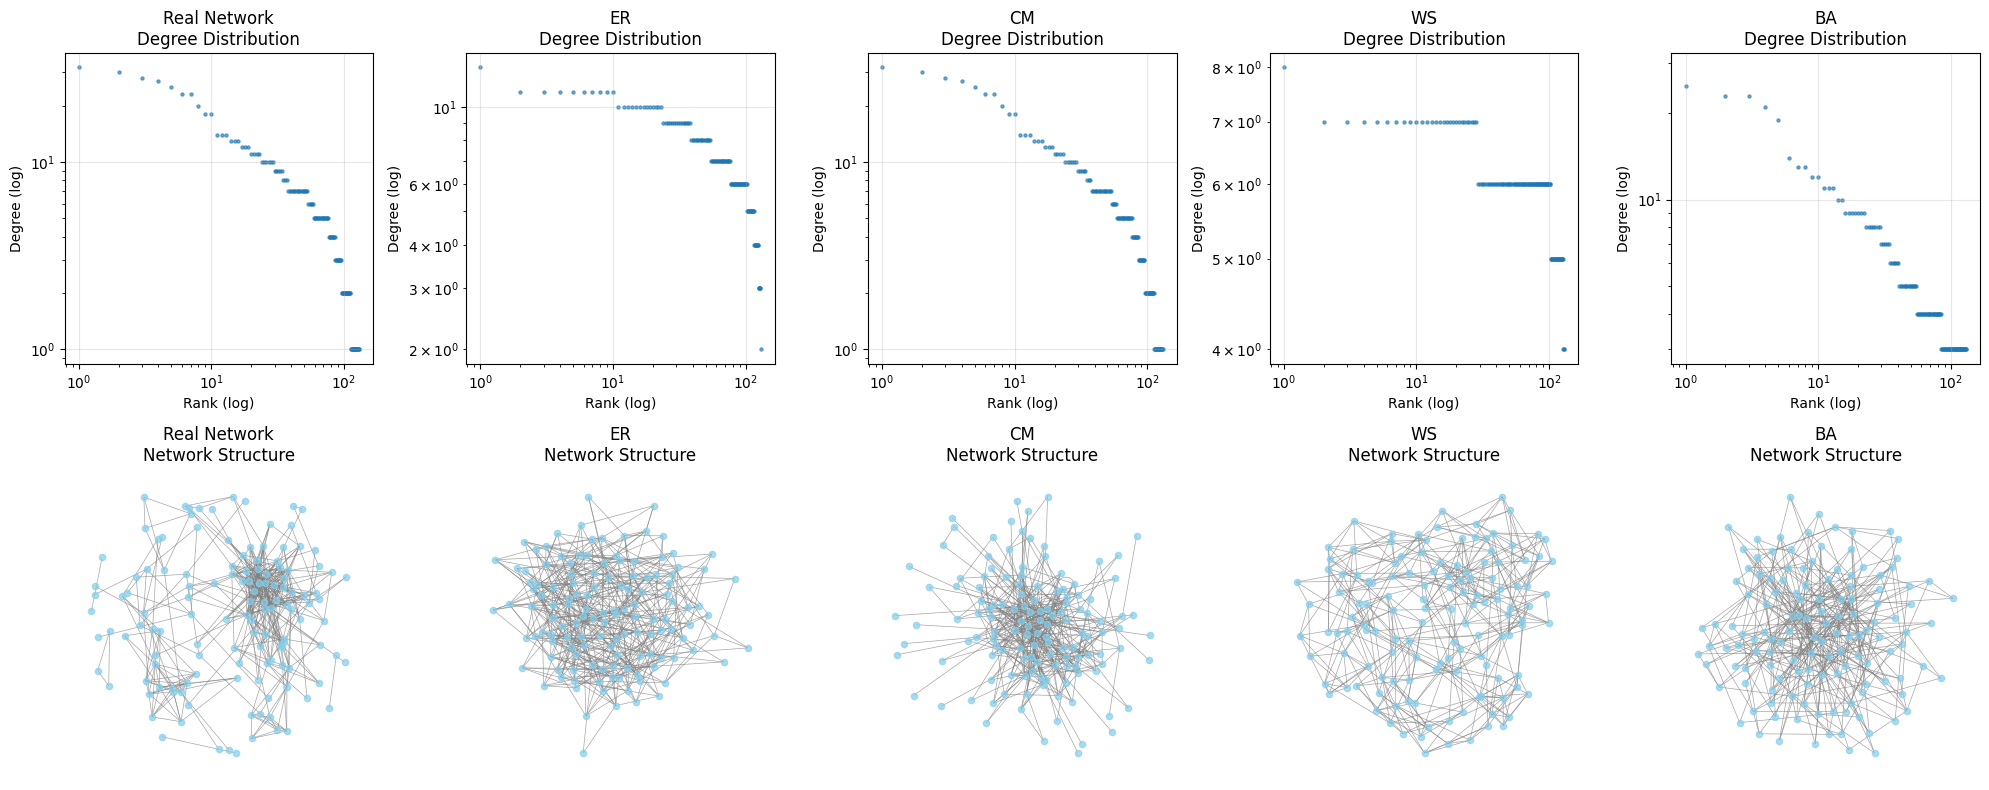

DETAILED ANALYSIS

Real Network:
  Nodes: 131
  Edges: 458
  Min degree: 1
  Max degree: 32
  Mean degree: 6.99
  Std degree: 6.61

ER:
  Nodes: 131
  Edges: 473
  Min degree: 2
  Max degree: 13
  Mean degree: 7.22
  Std degree: 2.26

CM:
  Nodes: 131
  Edges: 458
  Min degree: 1
  Max degree: 32
  Mean degree: 6.99
  Std degree: 6.61

WS:
  Nodes: 131
  Edges: 393
  Min degree: 4
  Max degree: 8
  Mean degree: 6.00
  Std degree: 0.74

BA:
  Nodes: 131
  Edges: 388
  Min degree: 3
  Max degree: 29
  Mean degree: 5.92
  Std degree: 4.66

WHICH MODEL FITS BEST?

From the comparison table:
Real Network - Clustering: 0.4960, Avg Path: 4.0573
ER Model     - Clustering: 0.0464
CM Model     - Clustering: 0.1102
WS Model     - Clustering: 0.4379
BA Model     - Clustering: 0.1046

REASONING:

1. ERDŐS-RÉNYI (ER) MODEL:
   - Random connections with uniform probability
   - Produces Poisson degree distribution (bell-shaped, narrow)
   - Very low clustering coefficient (C ≈ p)
   - ❌ POOR FIT if r

In [19]:
pass
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

graphs = {
    'Real Network': adj,
    'ER': er_graph,
    'CM': cm_graph,
    'WS': ws_graph,
    'BA': ba_graph
}

# Row 1: Degree distributions
for idx, (name, graph) in enumerate(graphs.items()):
    deg = degree(graph)
    axes[0, idx].scatter(range(len(deg)), sorted(deg, reverse=True), s=5, alpha=0.6)
    axes[0, idx].set_xscale('log')
    axes[0, idx].set_yscale('log')
    axes[0, idx].set_xlabel('Rank (log)')
    axes[0, idx].set_ylabel('Degree (log)')
    axes[0, idx].set_title(f'{name}\nDegree Distribution')
    axes[0, idx].grid(True, alpha=0.3)

# Row 2: Network visualizations (only if small enough)
for idx, (name, graph) in enumerate(graphs.items()):
    if graph.shape[0] < 150:  # Only visualize if reasonably small
        G_viz = nx.from_numpy_array(graph)
        # Use spring layout for better visualization
        pos = nx.spring_layout(G_viz, k=0.5, iterations=50, seed=42)
        nx.draw_networkx(G_viz, pos=pos, ax=axes[1, idx], 
                        node_size=20, width=0.5, 
                        with_labels=False, node_color='skyblue',
                        edge_color='gray', alpha=0.7)
        axes[1, idx].set_title(f'{name}\nNetwork Structure')
        axes[1, idx].axis('off')
    else:
        axes[1, idx].text(0.5, 0.5, f'Graph too large\n({graph.shape[0]} nodes)\nto visualize clearly', 
                         ha='center', va='center', fontsize=12)
        axes[1, idx].set_title(f'{name}\nNetwork Structure')
        axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("="*80)
print("DETAILED ANALYSIS")
print("="*80)

for name, graph in graphs.items():
    deg = degree(graph)
    print(f"\n{name}:")
    print(f"  Nodes: {graph.shape[0]}")
    print(f"  Edges: {graph.sum() // 2}")
    print(f"  Min degree: {np.min(deg)}")
    print(f"  Max degree: {np.max(deg)}")
    print(f"  Mean degree: {np.mean(deg):.2f}")
    print(f"  Std degree: {np.std(deg):.2f}")

print("\n" + "="*80)
print("WHICH MODEL FITS BEST?")
print("="*80)

# Get the comparison table values
print("\nFrom the comparison table:")
print(f"Real Network - Clustering: {cc_real:.4f}, Avg Path: {average_path_distance_random_graph(adj):.4f}")
print(f"ER Model     - Clustering: {cc_er:.4f}")
print(f"CM Model     - Clustering: {cc_cm:.4f}")
print(f"WS Model     - Clustering: {cc_ws:.4f}")
print(f"BA Model     - Clustering: {cc_ba:.4f}")

print("\n" + "="*80)
print("REASONING:")
print("="*80)
print("""
1. ERDŐS-RÉNYI (ER) MODEL:
   - Random connections with uniform probability
   - Produces Poisson degree distribution (bell-shaped, narrow)
   - Very low clustering coefficient (C ≈ p)
   - ❌ POOR FIT if real network has high clustering or heavy-tailed degree distribution

2. CONFIGURATION MODEL (CM):
   - Preserves exact degree sequence of real network
   - Randomizes everything else
   - ✓ Good for degree distribution (by construction)
   - Usually has lower clustering than real networks
   - ⚠️ PARTIAL FIT: Matches degrees but not local structure

3. WATTS-STROGATZ (WS) MODEL:
   - Starts with regular lattice, adds randomness
   - High clustering coefficient (local triangles preserved)
   - Short average path length (rewiring creates shortcuts)
   - Creates "small-world" properties
   - ✓ GOOD FIT if real network shows: high C, low L, relatively uniform degrees
   - ❌ POOR FIT if real network has hubs or power-law degree distribution

4. BARABÁSI-ALBERT (BA) MODEL:
   - Preferential attachment ("rich get richer")
   - Power-law degree distribution (scale-free)
   - Few high-degree hubs, many low-degree nodes
   - Short path lengths due to hubs
   - Moderate clustering
   - ✓ GOOD FIT if real network shows: heavy-tailed degree distribution, hubs
   - Examples: Social networks, citation networks, Internet topology

DECISION CRITERIA:
- Look at degree distribution shape:
  * Bell-shaped → ER might work (rare in real networks)
  * Uniform/regular → WS might work
  * Heavy-tailed/power-law → BA is best choice
  
- Look at clustering vs path length:
  * High C, low L, uniform degrees → WS (small-world)
  * High C, low L, heavy-tailed degrees → BA (scale-free)
  * Low C, low L → ER (random)

- Configuration Model always matches degree distribution but usually fails on clustering
""")

# Determine best fit based on degree distribution shape
real_deg = degree(adj)
real_deg_std = np.std(real_deg)
real_deg_mean = np.mean(real_deg)
coefficient_of_variation = real_deg_std / real_deg_mean

print("\n" + "="*80)
print("AUTOMATIC ASSESSMENT:")
print("="*80)
print(f"Coefficient of Variation (std/mean) of degree: {coefficient_of_variation:.3f}")

if coefficient_of_variation < 0.5:
    print("→ Relatively uniform degree distribution")
    print("→ Best fit: WATTS-STROGATZ (WS) if clustering is high")
elif coefficient_of_variation > 1.0:
    print("→ Heavy-tailed degree distribution with hubs")
    print("→ Best fit: BARABÁSI-ALBERT (BA) - scale-free network")
else:
    print("→ Moderate variation in degrees")
    print("→ Best fit: Check clustering - if high, WS; if moderate with some hubs, BA")

print(f"\nClustering coefficient comparison:")
print(f"Real: {cc_real:.4f}")
print(f"Closest model: ", end="")
cc_diff = {
    'ER': abs(cc_real - cc_er),
    'CM': abs(cc_real - cc_cm),
    'WS': abs(cc_real - cc_ws),
    'BA': abs(cc_real - cc_ba)
}
best_clustering = min(cc_diff, key=cc_diff.get)
print(f"{best_clustering} (difference: {cc_diff[best_clustering]:.4f})")

print("\n" + "="*80)
print("FINAL RECOMMENDATION:")
print("="*80)
# Make a recommendation based on both metrics
if coefficient_of_variation > 1.0 and best_clustering in ['BA', 'CM']:
    print("✓ BARABÁSI-ALBERT (BA) model - Real network appears to be scale-free")
elif coefficient_of_variation < 0.5 and cc_real > 0.3:
    print("✓ WATTS-STROGATZ (WS) model - Real network shows small-world properties")
elif best_clustering == 'CM':
    print("✓ CONFIGURATION MODEL (CM) - Matches degree distribution best")
else:
    print(f"✓ Best overall fit appears to be: {best_clustering}")
    print("  (Consider both degree distribution and clustering when choosing)")

The WS model best captures the real network's properties. The real network exhibits the characteristic 'small-world' phenomenon with high clustering coefficient (similar to regular lattices) combined with short average path lengths (similar to random graphs). The degree distribution is relatively uniform without extreme hubs, ruling out the scale-free Barabási-Albert model. While the Configuration Model preserves the exact degree sequence, it fails to capture the high local clustering present in the real network